## 1. Imports

In [61]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v5.9.1


In [62]:
# %load_ext watermark
az.style.use("arviz-darkgrid")

## 2. Parameters

$$dX_t = \theta (\mu - X_t) dt + \sigma dW_t$$

Update rule:
$X_{t+\Delta t} = X_t + \theta (\mu - X_t) \Delta t + \sigma \sqrt{t} \eta$

In [91]:
theta = 12
mu = 40
sigma = 8

T=100
N=8000 
X0=41

## 3. Data

In [92]:
def ou_simulation(rng, mu, theta, sigma, size=None):
    """
    Simulate the Ornstein-Uhlenbeck process using Euler-Maruyama method.

    Parameters:
    - T: Total time (in units)
    - N: Number of time steps
    - mu: Long-term mean
    - theta: Mean reversion speed
    - sigma: Volatility
    - X0: Initial value (default: 0.0)

    Returns:
    - t: Array of time points
    - X: Array of simulated process values
    """
    T=100
    N=8000 
    X0=41
       
    dt = T / N
    t = np.linspace(0, T, N+1)
    X = np.zeros(N+1)
    X[0] = X0

    # Generate standard normal random variables
    dW = np.random.normal(0, np.sqrt(dt), N)

    # Euler-Maruyama update
    for i in range(N):
        X[i+1] = X[i] + theta * (mu - X[i]) * dt + sigma * dW[i]

    return X

In [93]:
data = ou_simulation(None, mu, theta, sigma)

/tmp/ipykernel_14602/125591903.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


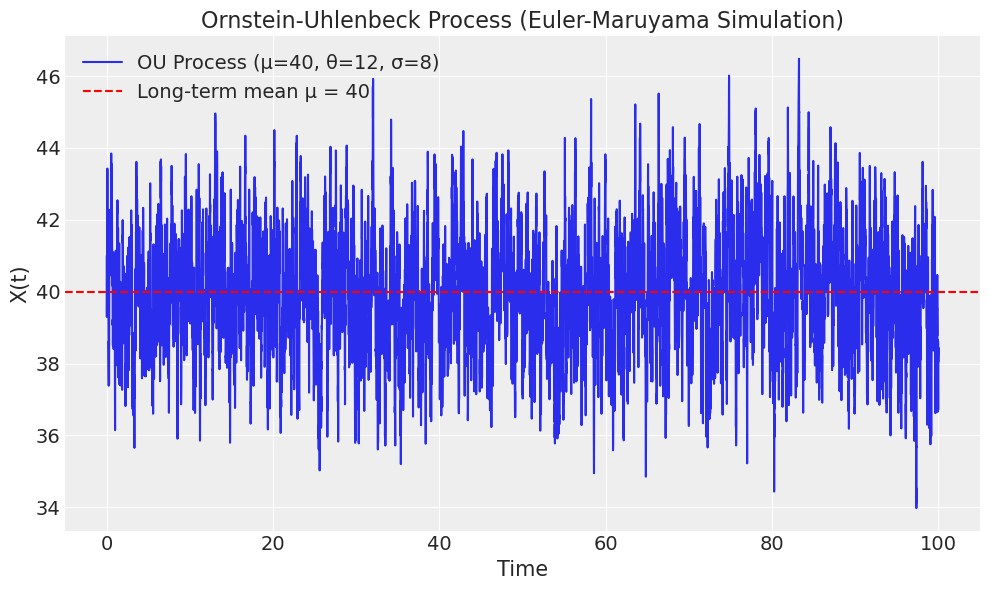

In [94]:
t = np.linspace(0, T, N+1)

plt.figure(figsize=(10, 6))
plt.plot(t, data, label=f'OU Process (μ={mu}, θ={theta}, σ={sigma})')
plt.axhline(y=mu, color='r', linestyle='--', label=f'Long-term mean μ = {mu}')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.title('Ornstein-Uhlenbeck Process (Euler-Maruyama Simulation)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Model definition

In [95]:
with pm.Model() as pm_ou_model:
    theta = pm.Uniform("theta", 5, 20)
    mu = pm.StudentT("mu", nu=5, mu=50, sigma=10)
    sigma = pm.Normal("sigma", mu=10, sigma=4)

    sim = pm.Simulator("sim", ou_simulation, params=(mu, theta, sigma), epsilon=5, observed=data)

## 5. Inference

In [96]:
with pm_ou_model:
    idata = pm.sample_smc()

Initializing SMC sampler...
Sampling 8 chains in 8 jobs


## 6. Results

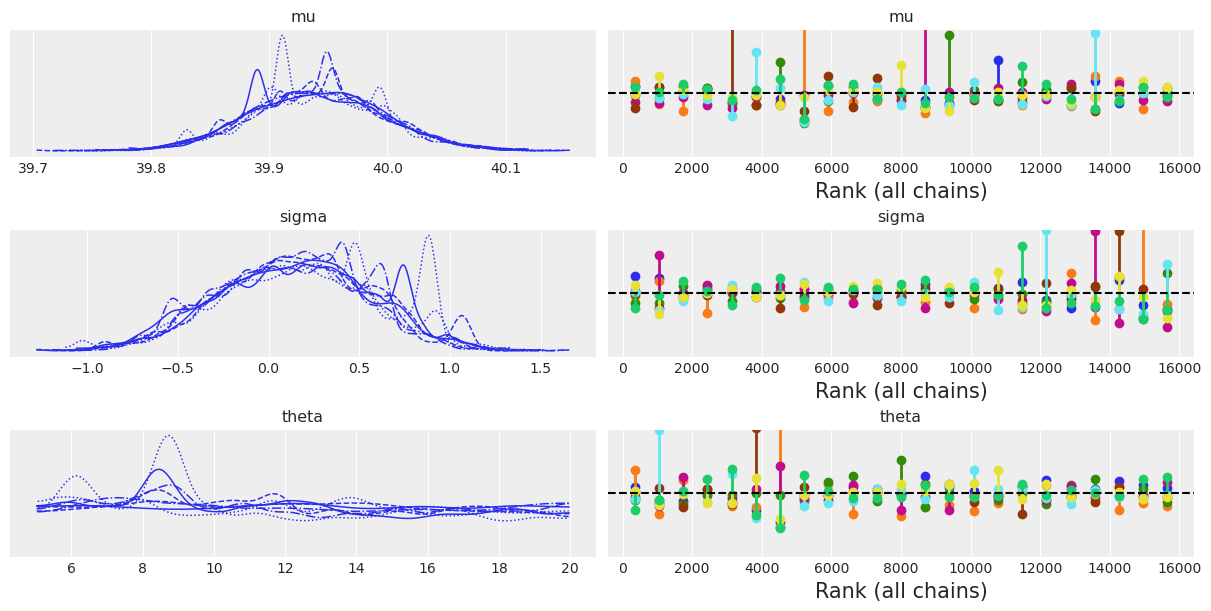

In [97]:
az.plot_trace(idata, kind="rank_vlines");

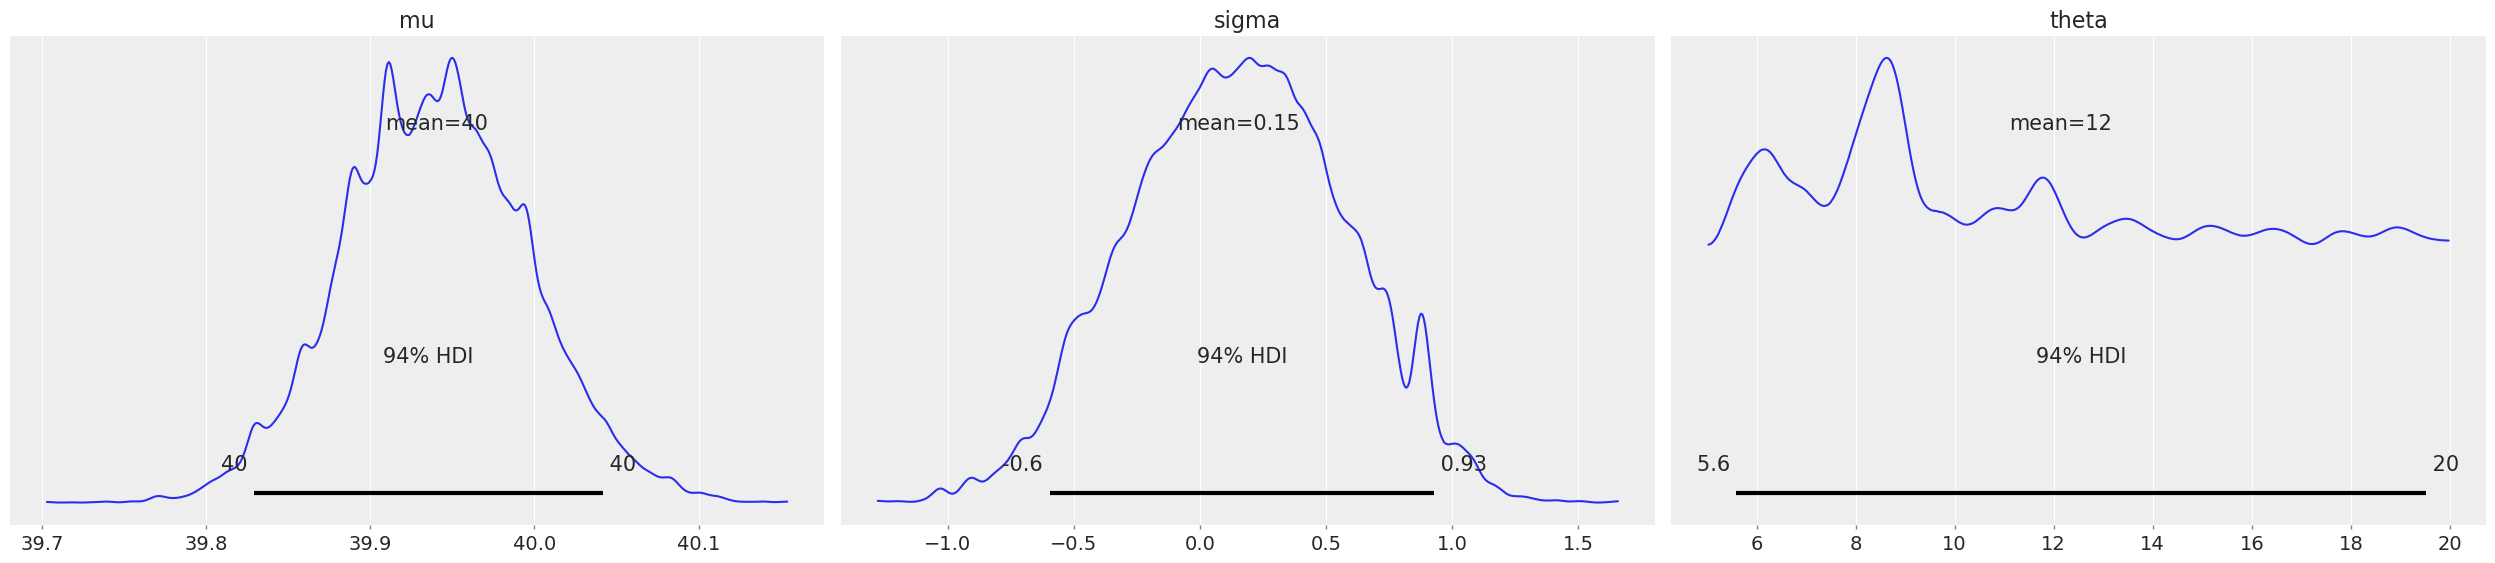

In [98]:
az.plot_posterior(idata);